# ISEL - Processamento de Imagem e Visão(PIV)
## Semestre de Inverno 2025/26
# <br>
###  <center> Trabalho Prático 1 </center>
###  <center> Trabalho nº 2.A – Contagem de Veículos em Imagens de Vídeo </center>
# </br>



Trabalho realizado por:


| Aluno | Número |
|-------|--------|
| **Ruben Zhang** | A51388 |
| **Rodrigo Neves** | A51452 |


<b> Turma 51D - Docente: Pedro Jorge </b>

<b>Objetivos:</b>


<b>Descrição:</b>


In [138]:
#Imports necessários ao longo do trabalho
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [139]:
def AbrirVideo(caminho, janela=False): #REFATORAR DPS SE NECESSARIO
    cap = cv2.VideoCapture(caminho)

    if not cap.isOpened():
        print(f"Error: Não conseguiu abrir o video em: {caminho}")
        return [], None, 0

    print("Video aberto com sucesso!")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = round(cap.get(cv2.CAP_PROP_FPS))
    if fps <= 0 or fps is None or fps != fps:  # fps != fps para apanhar NaN
        fps = 30

    frame_interval_ms = int(1000 / fps)
    print(f"Total frames: {frame_count}, FPS: {fps}")

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Fi do video alcançado ou erro na leitura do frame.")
            break
        frames.append(frame)
        if (janela):
            cv2.imshow("Video Frame", frame)
            tecla = cv2.waitKey(frame_interval_ms) & 0xFF
            if tecla == ord('q') or tecla == 27:
                break

    cap.release()
    cv2.destroyAllWindows()
    return frames, fps, frame_count


def EstimacaoImageFundo(caminho, n_amostras=24, guardar=False):
    cap = cv2.VideoCapture(caminho)

    if not cap.isOpened():
        print("Erro: não conseguiu abrir o vídeo!")
        return None

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Selecionar frames espaçados
    indices = np.linspace(0, total - 1, n_amostras).astype(int)

    frames = []

    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)

    cap.release()

    if len(frames) == 0:
        print("Erro: sem frames suficientes para calcular o fundo.")
        return None

    fundo = np.median(frames, axis=0).astype(np.uint8)

    if guardar:
        plt.imsave("fundo_estimado.jpg", fundo)

    plt.imshow(cv2.cvtColor(fundo, cv2.COLOR_BGR2RGB))
    plt.title("imagem do fundo estimado")
    plt.axis("off")
    plt.show()

    return fundo


def DetetarPixeisAtivos(frame, frame_fundo_estimado, limiar, mostrar=False):
    frameG = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fundoG = cv2.cvtColor(frame_fundo_estimado, cv2.COLOR_BGR2GRAY)
    diff = cv2.absdiff(frameG, fundoG) 
    
    _, bin_img = cv2.threshold(diff, limiar, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bin_img_not= np.bitwise_not(bin_img)
    if mostrar:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(frameG, cmap='gray')
        plt.title("Frame Original em Cizento")
        plt.subplot(1, 3, 2)
        plt.imshow(diff, cmap='gray')
        plt.title("Diferença entre cada frame e o fundo estimado")
        plt.subplot(1, 3, 3)
        plt.imshow(bin_img, cmap='gray')
        plt.title("Diferença em Binária")
        plt.show()

    # detetar, em cada frame, quais os píxeis que mudaram em relação ao fundo — 
    # ou seja, os píxeis que representam objetos em movimento (carros).    
    return bin_img, diff


def Morfologicos(bin_img):
    # 1. Opening para remover ruído
    k1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, k1)

    # 2. Closing para unir partes do carro e fechar buracos
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, k2)

    # 3. Dilatação leve para garantir que cada veículo é uma só região
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    img = cv2.dilate(img, k3)
    img = cv2.dilate(img, k3)
    img = cv2.dilate(img, k3)
    img = cv2.erode(img, k3)

    

    plt.imshow(img, cmap='binary')
    plt.show()

    return img


def DesenharLegendaContornos(contorno, img, label, velo, color=(0, 0, 0)):
    cv2.drawContours(img, [contorno], -1, color, 2) #Desenha os contornos na imagem original
    M = cv2.moments(contorno) #Obtem os momentos do contorno para calcular o centro
    cX = int(M["m10"]/M["m00"]) if M["m00"] != 0 else 0 #Calcula o centroide 
    cY = int(M["m01"]/M["m00"]) if M["m00"] != 0 else 0
    # Desenhar classificação
    cv2.putText(img, label, (cX - 20, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.7 , color, 2)
    # Desenhar ratio na linha abaixo
    cv2.putText(img, f"({velo:.3f})", (cX - 40, cY + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
#Contornos hull antes e depois
def ContornosHull(img_original, hulls, contornos):
    img_contornos = img_original.copy()
    img_hulls = img_original.copy()

    cv2.drawContours(img_contornos, contornos, -1, (0, 0, 0), 2)
    cv2.drawContours(img_hulls, hulls, -1, (0, 0, 255), 2)
    # Mostrar as duas imagens lado a lado
    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
    plt.title("Contornos Originais")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(img_hulls, cv2.COLOR_BGR2RGB))
    plt.title("Contornos com Convex Hull")
    plt.axis("off")

    plt.tight_layout()
    plt.show()



def DetecaoRegioesAtivas(img_bin, img_original):
    # Converter binário para formato ideal
    img = img_bin.copy()


    frame_out = img_original.copy()

    contornos, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    hulls = [cv2.convexHull(c) for c in contornos]
    veiculos = []
    IDVaiculo= 0
    for hull in hulls:
        if cv2.contourArea(hull) > 500:  # Filtrar pequenas regiões
            x, y, w, h = cv2.boundingRect(hull)
            veiculos.append((x, y, w, h))
            DesenharLegendaContornos(hull, frame_out, str(IDVaiculo), 0)
            IDVaiculo += 1

    cor_texto = (255, 255, 255)
    tamanho_texto = 0.7
 
    #Mete a legenda das peças
    cv2.putText(frame_out, f"2x2: {IDVaiculo}", (100, 500), 
    cv2.FONT_HERSHEY_SIMPLEX, tamanho_texto, cor_texto, 4)
    ContornosHull(frame_out, hulls, contornos)
    # Mostrar imagem final corretamente
    plt.figure(figsize=(6,5))
    plt.imshow(cv2.cvtColor(frame_out, cv2.COLOR_BGR2RGB))
    plt.title("Veículos Detetados")
    plt.axis("off")
    plt.show()

    return veiculos
    

            


In [140]:

def DesenharPontosVista(frame, pts_src):
    frameCopia= frame.copy()

    # Desenhar os pontos
    for p in pts_src:
        cv2.circle(frameCopia, tuple(map(int, p)), 4, (0, 0, 255), -1)  # Ponto em vermelho

    # Desenhar o polígono com os pontos
    cv2.polylines(frameCopia, [np.int32((pts_src[0], pts_src[1], pts_src[3], pts_src[2]))], isClosed=True, color=(255, 0, 0), thickness=2)
    
    plt.imshow(cv2.cvtColor(frameCopia, cv2.COLOR_BGR2RGB))
    plt.title("imagem com pontos da vista")
    plt.grid()
    plt.show()
    return frameCopia



def CorrigirPerspetiva(frame, pts_src, largura_dst, altura_dst):
    # 1. Verificar se o frame é válido
    if frame is None:
        print("Frame inválido!")
        return None
    
    altura_dst, largura_dst = frame.shape[:2]
    # 2. Criar os pontos destino, na mesma ordem que pts_src
    pts_dst = np.float32([
        [0, 0],                         # topo-esquerdo
        [largura_dst - 1, 0],           # topo-direito
        [0, altura_dst - 1],            # fundo-esquerdo
        [largura_dst - 1, altura_dst - 1]  # fundo-direito
    ])

    # 3. Calcular a matriz de homografia
    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)

    # 4. Aplicar a transformação de perspetiva para o tamanho desejado
    img_corrigida = cv2.warpPerspective(frame, matriz, (largura_dst, altura_dst))
    # Mostrar o resultado
    
    plt.imshow(cv2.cvtColor(img_corrigida, cv2.COLOR_BGR2RGB))
    plt.title("imagem corrigida da perspetiva")
    plt.grid()
    plt.show()

    return img_corrigida




In [141]:
def Histograma(img): #Calcula os histogramas dos três canais
    if img is None:
        print("Imagem inválida!")
        return
    
    canais = ['Blue', 'Green', 'Red']
    cores = ['b', 'g', 'r']

    plt.figure(figsize=(15, 4))

    for i, (canal, cor) in enumerate(zip(canais, cores)):
        plt.subplot(1, 3, i + 1)
        
        # Calcular histograma do canal i
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])

        plt.plot(hist, color=cor)
        plt.title(f'Histograma - Canal {canal}')
        plt.xlabel('Intensidade')
        plt.ylabel('Frequência')
        plt.xlim([0, 256])
        plt.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()


def Binarizacao(img):
    
    #Obtem o canal vermelho da imagem
    canal_r = img[:, :, 2]
    
    # Binarização adicional usando o canal vermelho
    # Peças LEGO têm valores elevados no canal R
    lower_r = 98
    upper_r = 255
    mascara_r = cv2.inRange(canal_r, lower_r, upper_r)

    mascara = cv2.bitwise_and(img, img, mask=mascara_r) # Aplica a máscara ao canal vermelho
    
    # Converter para escala de cinza e aplicar blur 
    gray = cv2.cvtColor(mascara, cv2.COLOR_BGR2GRAY)
    img_gaussian = cv2.medianBlur(gray, 13)

    # Aplicar limiarização de Otsu(adapta-se automaticamente) e binarização
    t, bin_result = cv2.threshold(img_gaussian, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) 
    return bin_result



def DesenharLegendaContornos(contorno, img, label, ratio, color=(0, 0, 0)):
    cv2.drawContours(img, [contorno], -1, color, 2) #Desenha os contornos na imagem original

    M = cv2.moments(contorno) #Obtem os momentos do contorno para calcular o centro
    cX = int(M["m10"]/M["m00"]) if M["m00"] != 0 else 0 #Calcula o centroide 
    cY = int(M["m01"]/M["m00"]) if M["m00"] != 0 else 0

    # Desenhar classificação
    cv2.putText(img, label, (cX - 20, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
    # Desenhar ratio na linha abaixo
    cv2.putText(img, f"({ratio:.3f})", (cX - 40, cY + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)


def avaliar_classificacao(L_verdadeiro, L_predito):
    classes = ["2x2", "2x4", "2x6", "2x8", "Indefinido"]
    matriz_confusao = confusion_matrix(L_verdadeiro, L_predito, labels=classes)

    # Número total de amostras
    total = np.sum(matriz_confusao)

    # Número de acertos = soma da diagonal principal
    acertos = np.trace(matriz_confusao)

    # Probabilidade de erro = 1 - (acertos / total)
    prob_erro = 1 - (acertos / total)

    # Mostra resultados
    print("Matriz de Confusão:")
    print("Linhas = Valor verdadeiro | Colunas = Valor predito\n")
    print(matriz_confusao)
    print("=="*20)
    print(f"Probabilidade de Erro: {(prob_erro * 100):.2f} %")
    
    plt.figure(figsize=(6, 5))
    
    # Mostrar matriz como imagem (com cores)
    plt.imshow(matriz_confusao, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Matriz de Confusão")
    plt.colorbar()

    # Definir rótulos dos eixos
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Escrever os valores nas células
    thresh = matriz_confusao.max() / 2.
    for i in range(matriz_confusao.shape[0]):
        for j in range(matriz_confusao.shape[1]):
            plt.text(j, i, format(matriz_confusao[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if matriz_confusao[i, j] > thresh else "black")

    plt.ylabel("Classe Verdadeira")
    plt.xlabel("Classe Predita")
    plt.tight_layout()
    plt.show()

    return matriz_confusao, prob_erro


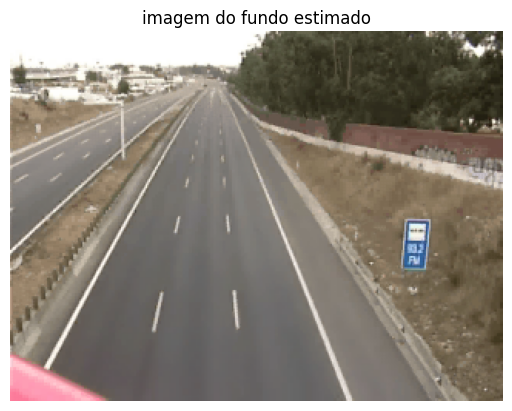

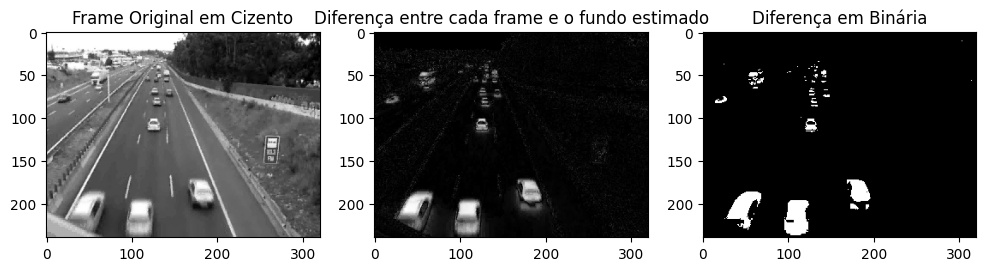

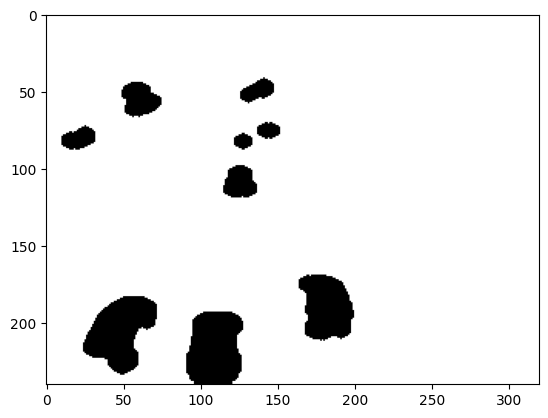

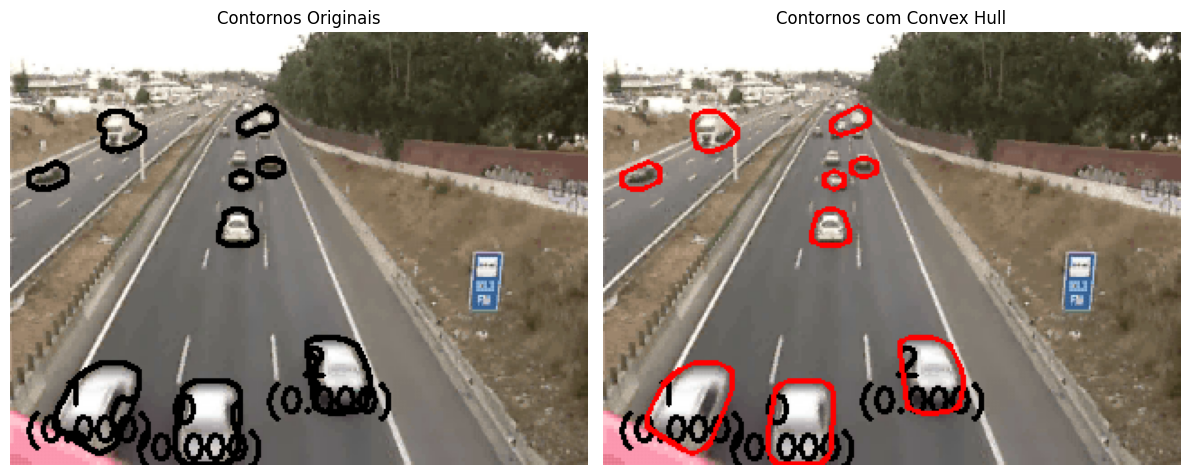

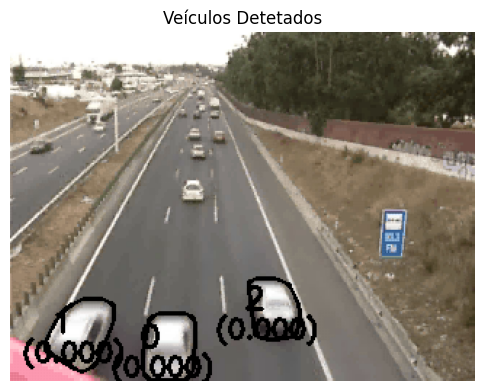

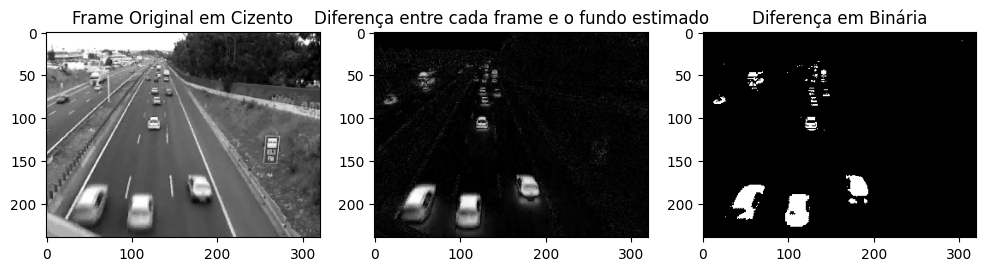

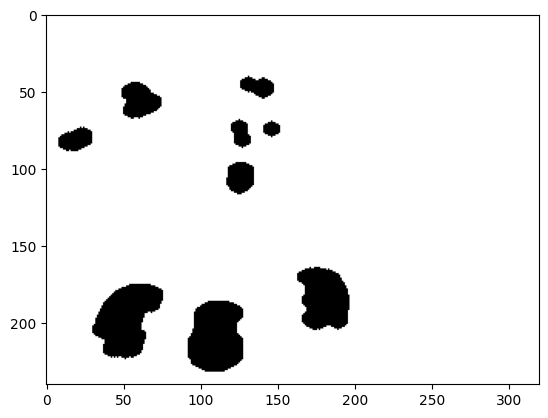

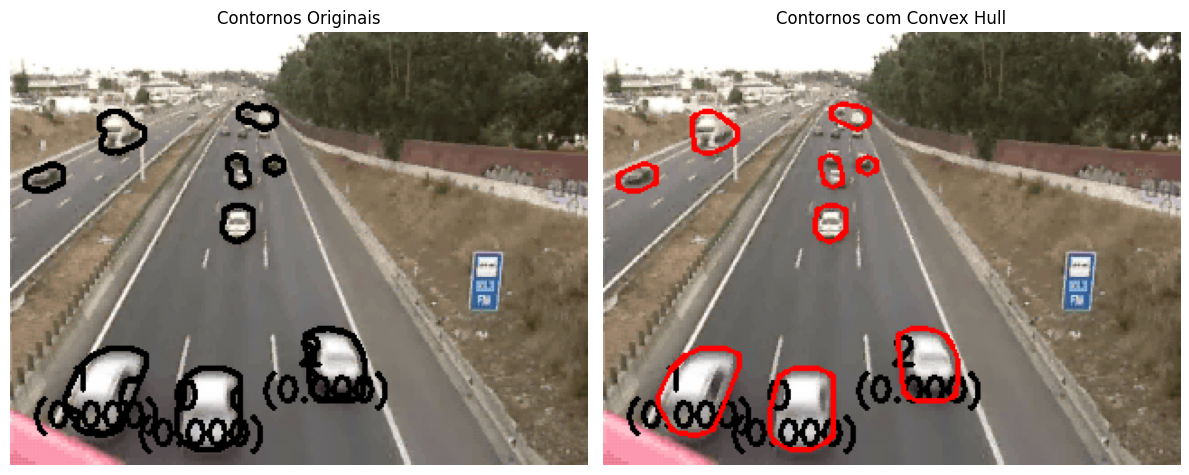

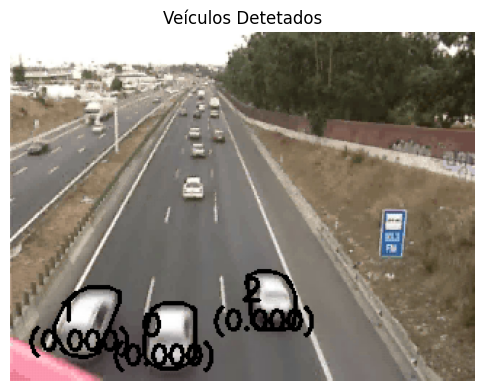

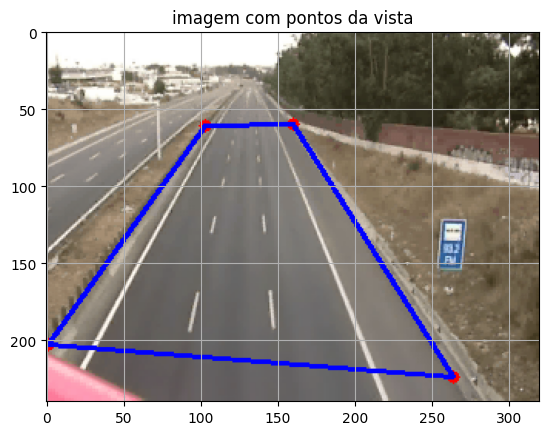

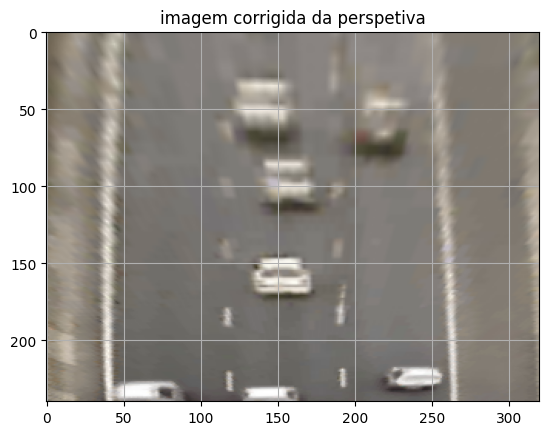

In [142]:
Ficheiro = "AutoEstrada.wm"
pts_src = np.float32([ [103, 61],# topo-esquerdo 
[160, 60], # topo-direito 
[1, 203], # fundo-esquerdo 
[264, 224] # fundo-direito 
])
# # [125, 38], # topo-esquerdo # [140, 42], # topo-direito # [24, 217], # fundo-esquerdo # [220, 240] 
largura_dst = 600
altura_dst = 800

# 1) Estimar o fundo
Fundo = EstimacaoImageFundo(Ficheiro)

# 2) Abrir o vídeo
cap = cv2.VideoCapture(Ficheiro)

# while True:
for i in range(2):
    ret, frame = cap.read()
    if not ret:
        break

    # 3) Deteção de píxeis ativos
    bin_img, diff = DetetarPixeisAtivos(frame, Fundo, 40, mostrar=True)

    # 4) Morfologia
    bin_clean = Morfologicos(bin_img)
    DetecaoRegioesAtivas(bin_clean, frame)

# 5) Corrigir perspetiva — só se quiseres visualizar!
DesenharPontosVista(Fundo, pts_src)
frame_corrigido = CorrigirPerspetiva(frame, pts_src, largura_dst, altura_dst)

cap.release()


